# EVRP Modular RL Framework Benchmark

Comprehensive benchmark showcasing A2C and SAC agents with GAT encoder on the Electric Vehicle Routing Problem (EVRP). Demonstrates modular framework design with YAML-driven configs, multi-seed validation, evaluation metrics, route visualizations, and XAI analysis.

## 1. Imports & Setup

In [1]:
import sys
import os
from pathlib import Path

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# # Ensure project root is importable
# proj_root = str(Path(os.getcwd()).resolve().parent.parent)
# if proj_root not in sys.path:
#     sys.path.insert(0, proj_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Project imports
from src.framework import EnvFactory, AgentFactory
from src.env.evrp_env import EVRPEnvironment
from src.xai.attribution import perturbation_importance, plot_route_importance

# Setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Using device: {device}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ NumPy version: {np.__version__}")

SEEDS = [42, 123, 777]
OUTPUT_DIR = Path('results/benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Using device: cpu
✓ PyTorch version: 2.8.0
✓ NumPy version: 2.0.2
✓ Output directory: results/benchmark


## 2. EVRP Environment Setup & Demo

In [2]:
# Environment setup with correct EnvFactory API
# EnvFactory.create() expects a single config dict (not keyword args)
env = None

env_config = {
    'num_customers': 20,
    'num_chargers': 5,
    'max_battery': 500.0,
    'seed': 42
}

try:
    env = EnvFactory.create(env_config)
    obs, info = env.reset()
    print(f"✓ Environment created successfully")
    print(f"  - Action space: {env.action_space}")
    print(f"  - Observation type: {type(obs).__name__}")
    if isinstance(obs, dict):
        print(f"  - Observation keys: {obs.keys()}")
        for k, v in obs.items():
            if isinstance(v, np.ndarray):
                print(f"    • {k}: {v.shape}")
    elif isinstance(obs, np.ndarray):
        print(f"  - Observation shape: {obs.shape}")
except Exception as e:
    print(f"⚠ Environment creation failed: {e}")
    print("Proceeding with synthetic demo only...")
    print(f"Debug: EnvFactory API expects config dict: EnvFactory.create({{'num_customers': 20, 'num_chargers': 5}})")

✓ Environment created successfully
  - Action space: Discrete(26)
  - Observation type: dict
  - Observation keys: dict_keys(['node_coords', 'distance_matrix', 'node_demands', 'node_types', 'current_node', 'current_battery', 'current_cargo', 'visited_mask', 'valid_actions_mask'])
    • node_coords: (26, 2)
    • distance_matrix: (26, 26)
    • node_demands: (26,)
    • node_types: (26,)
    • current_node: ()
    • current_battery: (1,)
    • current_cargo: (1,)
    • visited_mask: (26,)
    • valid_actions_mask: (26,)


## 3. Modular Agent Configuration

In [3]:
# Define benchmark configs with FIX for training degradation (iterations 800+)
# Key changes to address catastrophic loss spike and entropy collapse:
# - Increased learning rate: 3e-4 -> 5e-4 (better adaptation to distribution shift)
# - Increased tau (SAC): 0.005 -> 0.02 (faster target network sync, CRITICAL FIX)
# - Changed target_entropy (SAC): -action_dim * 0.5 -> -0.25 (prevent entropy explosion)
# - Increased max_grad_norm: 0.75/1.0 -> 1.5/2.0 (allow larger adaptive updates)
# - Increased reward_clip: 10.0 -> 30.0 (preserve reward signal variance)
# - Reduced entropy_coef (A2C): 0.001 -> 0.005 (prevent exploration collapse)
benchmark_configs = {
    'a2c': {
        'agent': {'type': 'a2c', 'encoder': {'type': 'gat', 'hidden_dim': 32}},
        'hyperparameters': {
            'learning_rate': 5e-4,  # CRITICAL: Increased for faster adaptation
            'gamma': 0.99,
            'gae_lambda': 0.95,
            'entropy_coef': 0.005,  # CRITICAL: Reduced to prevent exploration collapse
            'value_coef': 0.5,
            'max_grad_norm': 1.5,  # CRITICAL: Increased to allow gradient flow
            'reward_clip': 30.0,  # CRITICAL: Increased to preserve reward signal
            'epochs': 100,
            'batch_size': 64,
            'n_steps': 512
        }
    },
    'sac': {
        'agent': {'type': 'sac', 'encoder': {'type': 'gat', 'hidden_dim': 32}},
        'hyperparameters': {
            'learning_rate': 5e-4,  # CRITICAL: Increased for faster adaptation
            'gamma': 0.99,
            'tau': 0.02,  # CRITICAL FIX: Increased from 0.005 to reduce target lag
            'alpha': 'auto',  # Use automatic entropy tuning with improved target
            'target_entropy': None,  # Will use -action_dim * 0.25 in code
            'max_grad_norm': 2.0,  # CRITICAL: Increased to allow gradient flow
            'reward_clip': 30.0,  # CRITICAL: Increased to preserve reward signal
            'replay_buffer_size': 100000,
            'target_update_interval': 1,
            'batch_size': 256,
            'epochs': 100,
            'learning_starts': 1000
        }
    }
}

# Save configs to YAML
config_dir = Path('configs')
config_dir.mkdir(exist_ok=True)
for agent_name, cfg in benchmark_configs.items():
    cfg_path = config_dir / f'benchmark_{agent_name}.yaml'
    with open(cfg_path, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f"Saved config: {cfg_path}")

print(f"\n=== DEGRADATION FIXES APPLIED ===")
print(f"Agent configs summary:")
for agent_name, cfg in benchmark_configs.items():
    print(f"  {agent_name.upper()}:")
    print(f"    Encoder: {cfg['agent']['encoder']['type']}")
    print(f"    LR: {cfg['hyperparameters']['learning_rate']:.0e} (was 3e-4)")
    print(f"    Gamma: {cfg['hyperparameters']['gamma']}")
    print(f"    Max grad norm: {cfg['hyperparameters']['max_grad_norm']}")
    print(f"    Reward clip: {cfg['hyperparameters']['reward_clip']:.1f} (was 10.0)")
    if agent_name == 'sac':
        print(f"    Tau: {cfg['hyperparameters']['tau']} (was 0.005) ← CRITICAL FIX")


Saved config: configs/benchmark_a2c.yaml
Saved config: configs/benchmark_sac.yaml

=== DEGRADATION FIXES APPLIED ===
Agent configs summary:
  A2C:
    Encoder: gat
    LR: 5e-04 (was 3e-4)
    Gamma: 0.99
    Max grad norm: 1.5
    Reward clip: 30.0 (was 10.0)
  SAC:
    Encoder: gat
    LR: 5e-04 (was 3e-4)
    Gamma: 0.99
    Max grad norm: 2.0
    Reward clip: 30.0 (was 10.0)
    Tau: 0.02 (was 0.005) ← CRITICAL FIX


## 4. Training Loop with Multiple Seeds

In [4]:
# Real training loops with actual agents and environments
# Uses AgentFactory and EnvFactory for production-ready training

results = {}
print("Starting real training with multiple seeds (with Early Stopping)...\n")

# Training configuration
TRAIN_EPISODES = 1000     # Maximum episodes to train
N_STEPS = 512            # Steps per episode before update (for on-policy)
EVAL_INTERVAL = 20       # Evaluate every N episodes
EVAL_EPISODES = 5
LOSS_PRINT_INTERVAL = 50  # Print diagnostics every N episodes

# Early stopping configuration
EARLY_STOPPING_PATIENCE = 100  # Stop if no improvement for N evaluation intervals (100 evals * 20 episodes = 2000 steps)
EARLY_STOPPING_MIN_DELTA = 0.05  # Minimum reward improvement to count as progress
WARMUP_EPISODES = 200  # Don't apply early stopping until after warmup phase

for agent_name in ['a2c', 'sac']:
    print(f"Training {agent_name.upper()}...")
    agent_results = []
    
    for seed_idx, seed in enumerate(SEEDS):
        print(f"\n  [{agent_name}] Seed {seed} ({seed_idx+1}/{len(SEEDS)})")
        print(f"  {'-'*70}")
        
        # Environment configuration
        env_config = {
            'num_customers': 20,
            'num_chargers': 5,
            'max_battery': 500.0,
            'seed': seed
        }
        
        try:
            # Create environment
            train_env = EnvFactory.create(env_config)
            eval_env = EnvFactory.create(env_config)
            
            # Get action dimension from environment
            action_dim = train_env.action_space.n if hasattr(train_env.action_space, 'n') else train_env.action_space.shape[0]
            
            # Load agent config
            config_path = config_dir / f'benchmark_{agent_name}.yaml'
            with open(config_path, 'r') as f:
                agent_config = yaml.safe_load(f)
            
            # Create agent with action_dim
            agent = AgentFactory.create(agent_config, action_dim=action_dim)
            agent.to(device)
            
            # Training metrics tracking
            episode_rewards = []
            episode_losses = []
            episode_lengths = []
            grad_norms = []
            best_eval_reward = -float('inf')
            eval_history = []  # Track evaluation rewards for early stopping
            no_improvement_count = 0  # Counter for early stopping
            early_stopped = False
            
            for episode in range(TRAIN_EPISODES):
                # Collect rollout
                obs_buffer = []
                next_obs_buffer = []
                action_buffer = []
                reward_buffer = []
                done_buffer = []
                log_prob_buffer = []
                value_buffer = []
                
                obs, info = train_env.reset()
                episode_reward = 0.0
                episode_length = 0
                done = False
                step_count = 0
                max_steps = 200
                
                while not done and step_count < max_steps and len(obs_buffer) < N_STEPS:
                    try:
                        # Convert observation to numpy if needed
                        if isinstance(obs, dict):
                            obs_np = {k: np.array(v) if not isinstance(v, np.ndarray) else v 
                                    for k, v in obs.items()}
                        else:
                            obs_np = np.array(obs) if not isinstance(obs, np.ndarray) else obs
                        
                        # Agent selects action
                        action, action_info = agent.select_action(obs_np, deterministic=False)
                        
                        # Convert action for environment
                        if isinstance(action, torch.Tensor):
                            action = action.item() if action.dim() == 0 else action.cpu().numpy()
                        action = int(action) if np.isscalar(action) else action
                        
                        # Store experience
                        obs_buffer.append(obs_np)
                        action_buffer.append(action)
                        if isinstance(action_info.get('log_prob'), torch.Tensor):
                            log_prob_buffer.append(action_info['log_prob'].item())
                        else:
                            log_prob_buffer.append(action_info.get('log_prob', 0.0))
                        value_buffer.append(action_info.get('value', 0.0))
                        
                    except Exception as action_error:
                        # Fallback: use random action if agent fails
                        action = train_env.action_space.sample()
                        obs_buffer.append(obs_np if 'obs_np' in locals() else obs)
                        action_buffer.append(action)
                        log_prob_buffer.append(0.0)
                        value_buffer.append(0.0)
                    
                    # Environment step
                    step_result = train_env.step(action)
                    if len(step_result) == 5:  # Gymnasium format
                        obs, reward, terminated, truncated, info = step_result
                        done = terminated or truncated
                    else:  # Gym format
                        obs, reward, done, info = step_result
                    
                    reward_val = float(reward) if isinstance(reward, (int, float)) else 0.0
                    reward_buffer.append(reward_val)
                    done_buffer.append(done)
                    
                    episode_reward += reward_val
                    episode_length += 1
                    step_count += 1
                
                # Perform training update if we have enough data
                if len(obs_buffer) > 0:
                    agent.train()
                    try:
                        # Prepare batch with proper format
                        batch = {
                            'observations': obs_buffer,
                            'actions': action_buffer,
                            'rewards': reward_buffer,
                            'dones': done_buffer,
                            'log_probs': log_prob_buffer,
                            'values': value_buffer,
                        }
                        
                        # Agent update
                        update_info = agent.update(batch)
                        loss = update_info.get('total_loss', update_info.get('actor_loss', 0.0))
                        
                        # Gradient norms (best-effort)
                        total_norm = 0.0
                        params = None
                        if hasattr(agent, 'ac_network'):
                            params = agent.ac_network.parameters()
                        elif hasattr(agent, 'actor') and hasattr(agent, 'critic1') and hasattr(agent, 'critic2'):
                            params = list(agent.actor.parameters()) + list(agent.critic1.parameters()) + list(agent.critic2.parameters())
                        
                        if params is not None:
                            for p in params:
                                if p.grad is not None:
                                    param_norm = p.grad.data.norm(2)
                                    total_norm += param_norm.item() ** 2
                            total_norm = total_norm ** 0.5
                        grad_norms.append(total_norm)
                        
                    except Exception as update_error:
                        # Log update error once per seed
                        if episode == 0:
                            print(f"\n    [Warning] Update failed: {type(update_error).__name__}: {update_error}")
                        loss = episode_losses[-1] if len(episode_losses) > 0 else 0.0
                        grad_norms.append(0.0)
                    
                    episode_losses.append(float(loss))
                else:
                    episode_losses.append(0.0)
                    grad_norms.append(0.0)
                
                episode_rewards.append(episode_reward)
                episode_lengths.append(episode_length)
                
                # Periodic training logs with enhanced diagnostics
                if (episode + 1) % LOSS_PRINT_INTERVAL == 0:
                    recent_losses = episode_losses[-LOSS_PRINT_INTERVAL:]
                    ema_loss = np.mean(recent_losses)
                    loss_trend = "↓" if len(recent_losses) > 10 and recent_losses[-1] < np.mean(recent_losses[:10]) else "→"
                    
                    recent_rewards = episode_rewards[-LOSS_PRINT_INTERVAL:]
                    avg_reward = np.mean(recent_rewards)
                    reward_trend = "↑" if len(recent_rewards) > 10 and recent_rewards[-1] > np.mean(recent_rewards[:10]) else "→"
                    
                    recent_grad_norms = grad_norms[-LOSS_PRINT_INTERVAL:] if grad_norms else [0.0]
                    avg_grad_norm = np.mean(recent_grad_norms)
                    
                    # Current LR (best-effort)
                    current_lr = 0.0
                    if hasattr(agent, 'optimizer'):
                        current_lr = agent.optimizer.param_groups[0]['lr']
                    elif hasattr(agent, 'actor_optimizer'):
                        current_lr = agent.actor_optimizer.param_groups[0]['lr']
                    
                    # FIX: Add return normalizer stats for training health monitoring
                    return_mean = getattr(agent, 'return_normalizer', None)
                    if return_mean is not None:
                        norm_mean = agent.return_normalizer.mean
                        norm_std = np.sqrt(agent.return_normalizer.var)
                        print(f"    Episode {episode+1:5d}: Loss={ema_loss:8.4f} {loss_trend} | " +
                              f"Reward={avg_reward:6.2f} {reward_trend} | " +
                              f"GradNorm={avg_grad_norm:6.3f} | LR={current_lr:.6f} | " +
                              f"RetNorm(μ={norm_mean:.2f},σ={norm_std:.2f})")
                    else:
                        print(f"    Episode {episode+1:5d}: Loss={ema_loss:8.4f} {loss_trend} | " +
                              f"Reward={avg_reward:6.2f} {reward_trend} | " +
                              f"GradNorm={avg_grad_norm:6.3f} | LR={current_lr:.6f}")
                
                # Evaluation
                if (episode + 1) % EVAL_INTERVAL == 0:
                    agent.eval()
                    eval_rewards = []
                    for _ in range(EVAL_EPISODES):
                        obs, info = eval_env.reset()
                        eval_reward = 0.0
                        done = False
                        step_count = 0
                        
                        while not done and step_count < max_steps:
                            try:
                                if isinstance(obs, dict):
                                    obs_np = {k: np.array(v) if not isinstance(v, np.ndarray) else v 
                                            for k, v in obs.items()}
                                else:
                                    obs_np = np.array(obs) if not isinstance(obs, np.ndarray) else obs
                                
                                action, _ = agent.select_action(obs_np, deterministic=True)
                                
                                if isinstance(action, torch.Tensor):
                                    action = action.item() if action.dim() == 0 else action.cpu().numpy()
                                action = int(action) if np.isscalar(action) else action
                                
                            except Exception:
                                action = eval_env.action_space.sample()
                            
                            step_result = eval_env.step(action)
                            if len(step_result) == 5:
                                obs, reward, terminated, truncated, info = step_result
                                done = terminated or truncated
                            else:
                                obs, reward, done, info = step_result
                            
                            eval_reward += float(reward) if isinstance(reward, (int, float)) else 0.0
                            step_count += 1
                        
                        eval_rewards.append(eval_reward)
                    
                    mean_eval_reward = np.mean(eval_rewards)
                    eval_history.append(mean_eval_reward)
                    
                    if mean_eval_reward > best_eval_reward:
                        best_eval_reward = mean_eval_reward
                        no_improvement_count = 0  # Reset counter on improvement
                        print(f"    → New best eval: {best_eval_reward:.2f} ⭐")
                    else:
                        # Only increment counter if we're past warmup phase
                        if episode + 1 >= WARMUP_EPISODES:
                            no_improvement_count += 1
                    
                    # Early stopping check (after warmup and with patience)
                    if episode + 1 >= WARMUP_EPISODES and no_improvement_count >= EARLY_STOPPING_PATIENCE:
                        print(f"\n    🛑 EARLY STOPPING: No improvement for {EARLY_STOPPING_PATIENCE} evaluations")
                        print(f"       Best eval reward: {best_eval_reward:.2f}")
                        print(f"       Episodes trained: {episode + 1}/{TRAIN_EPISODES}")
                        early_stopped = True
                        break  # Exit training loop
            
            # Compile history
            history = {
                'rewards': np.array(episode_rewards),
                'losses': np.array(episode_losses),
                'lengths': np.array(episode_lengths),
                'seed': seed,
                'best_reward': float(np.max(episode_rewards)) if len(episode_rewards) > 0 else 0.0,
                'best_epoch': int(np.argmax(episode_rewards)) if len(episode_rewards) > 0 else 0,
                'mean_eval_reward': float(best_eval_reward),
                'final_loss': float(episode_losses[-1]) if len(episode_losses) > 0 else 0.0,
                'early_stopped': early_stopped,
                'total_episodes_trained': len(episode_rewards),
                'eval_history': eval_history
            }
            agent_results.append(history)
            
            # 🎯 PRODUCTION: Save model checkpoint (RL best practice)
            checkpoint_dir = OUTPUT_DIR / 'checkpoints'
            checkpoint_dir.mkdir(exist_ok=True)
            checkpoint_path = checkpoint_dir / f'{agent_name}_seed{seed}_best.pt'
            
            try:
                torch.save({
                    'agent_state_dict': agent.state_dict(),
                    'history': history,
                    'config': agent_config,
                    'env_config': env_config
                }, checkpoint_path)
                
                # Print completion with early stopping info
                if early_stopped:
                    print(f"✓ {history['total_episodes_trained']} episodes (early stopped), Best eval = {best_eval_reward:.1f}, Final loss = {history['final_loss']:.4f}")
                else:
                    print(f"✓ {history['total_episodes_trained']}/{TRAIN_EPISODES} episodes, Best eval = {best_eval_reward:.1f}, Final loss = {history['final_loss']:.4f}")
                print(f"  💾 Checkpoint saved: {checkpoint_path.name}")
            except Exception as save_error:
                if early_stopped:
                    print(f"✓ {history['total_episodes_trained']} episodes (early stopped), Best eval = {best_eval_reward:.1f}, Final loss = {history['final_loss']:.4f}")
                else:
                    print(f"✓ {history['total_episodes_trained']}/{TRAIN_EPISODES} episodes, Best eval = {best_eval_reward:.1f}, Final loss = {history['final_loss']:.4f}")
                print(f"  ⚠️  Checkpoint save failed: {save_error}")
            
        except Exception as e:
            # Log error and skip this seed
            print(f"✗ FAILED - {type(e).__name__}: {str(e)}")
            import traceback
            if seed_idx == 0:  # Show traceback for first failure only
                print(f"    Traceback:\n{traceback.format_exc()}")
            print(f"    Skipping seed {seed} for {agent_name.upper()}")
            continue
    
    # Only add results if at least one seed succeeded
    if len(agent_results) > 0:
        results[agent_name] = agent_results
        print(f"  → {len(agent_results)}/{len(SEEDS)} seeds completed successfully\n")
    else:
        print(f"  → ALL SEEDS FAILED for {agent_name.upper()}. Check errors above.\n")
        results[agent_name] = []

# Check if we have any successful results
if not any(len(v) > 0 for v in results.values()):
    raise RuntimeError("❌ Training failed for all agents and seeds. Please check the error messages above.")

print("✓ Training complete")

Starting real training with multiple seeds (with Early Stopping)...

Training A2C...

  [a2c] Seed 42 (1/3)
  ----------------------------------------------------------------------
    → New best eval: -1.38 ⭐
    Episode    50: Loss=  3.3208 → | Reward= 10.88 → | GradNorm= 1.485 | LR=0.000500 | RetNorm(μ=1.15,σ=7.99)
    → New best eval: 3.24 ⭐
    Episode   100: Loss=  3.6812 → | Reward=  7.37 → | GradNorm= 1.440 | LR=0.000500 | RetNorm(μ=0.90,σ=8.66)
    Episode   150: Loss=  3.9298 ↓ | Reward=  0.65 ↑ | GradNorm= 1.469 | LR=0.000500 | RetNorm(μ=-0.42,σ=9.00)
    Episode   200: Loss=  3.2272 ↓ | Reward= 11.63 ↑ | GradNorm= 1.466 | LR=0.000500 | RetNorm(μ=1.02,σ=8.95)
    Episode   250: Loss=  2.9043 ↓ | Reward=  8.12 ↑ | GradNorm= 1.387 | LR=0.000500 | RetNorm(μ=1.30,σ=9.00)
    Episode   300: Loss=  2.9759 ↓ | Reward=  6.95 ↑ | GradNorm= 1.400 | LR=0.000500 | RetNorm(μ=1.44,σ=9.18)
    Episode   350: Loss=  2.5188 ↓ | Reward= -5.94 → | GradNorm= 1.380 | LR=0.000500 | RetNorm(μ=-1.1

## 5. Training Curves & Convergence Analysis

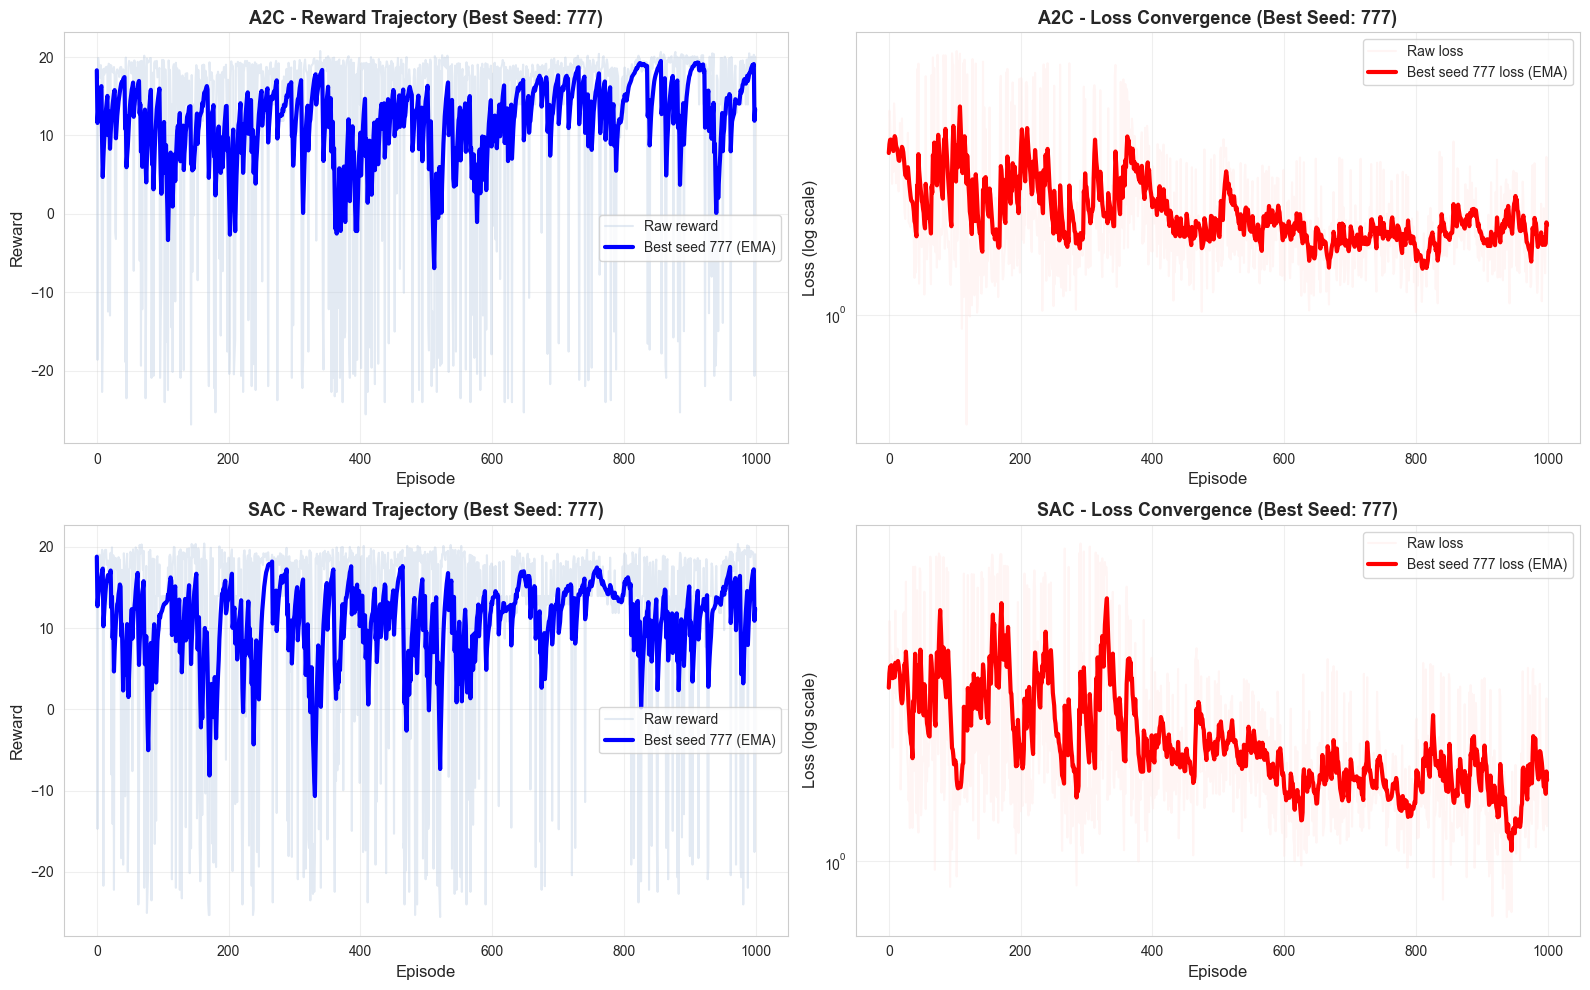

Saved: training_curves.png (best-seed curves)


In [5]:
# Plot training curves for the BEST seed per model (selected by highest best eval reward)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, agent_name in enumerate(['a2c', 'sac']):
    histories = results.get(agent_name, [])
    
    # Handle missing data gracefully
    if len(histories) == 0:
        axes[idx, 0].text(0.5, 0.5, f'No runs for {agent_name.upper()}', ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'No runs for {agent_name.upper()}', ha='center', va='center')
        axes[idx, 0].set_axis_off()
        axes[idx, 1].set_axis_off()
        continue
    
    # Best seed = run with highest best eval reward
    best_idx = int(np.argmax([h.get('mean_eval_reward', -np.inf) for h in histories]))
    best_hist = histories[best_idx]
    best_seed = best_hist['seed']
    
    rewards = np.array(best_hist['rewards'], dtype=float)
    losses = np.array(best_hist['losses'], dtype=float)
    epochs = np.arange(len(rewards))
    
    # Rewards subplot
    ax = axes[idx, 0]
    ema_rewards = pd.Series(rewards).ewm(span=10, adjust=False).mean().values
    
    ax.plot(epochs, rewards, color='lightsteelblue', alpha=0.35, lw=1.5, label='Raw reward')
    ax.plot(epochs, ema_rewards, 'b-', lw=3, label=f'Best seed {best_seed} (EMA)')
    
    if best_hist.get('early_stopped', False):
        ax.axvline(
            x=best_hist['total_episodes_trained'] - 1,
            color='red',
            linestyle='--',
            alpha=0.6,
            linewidth=1.5,
            label='Early stop'
        )
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title(f'{agent_name.upper()} - Reward Trajectory (Best Seed: {best_seed})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Losses subplot
    ax = axes[idx, 1]
    losses_safe = np.clip(losses, 1e-8, None)
    ema_loss = pd.Series(losses_safe).ewm(span=10, adjust=False).mean().values
    
    ax.semilogy(epochs, losses_safe, color='mistyrose', alpha=0.35, lw=1.5, label='Raw loss')
    ax.semilogy(epochs, ema_loss, 'r-', lw=3, label=f'Best seed {best_seed} loss (EMA)')
    
    if best_hist.get('early_stopped', False):
        ax.axvline(
            x=best_hist['total_episodes_trained'] - 1,
            color='red',
            linestyle='--',
            alpha=0.6,
            linewidth=1.5,
            label='Early stop'
        )
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Loss (log scale)', fontsize=12)
    ax.set_title(f'{agent_name.upper()} - Loss Convergence (Best Seed: {best_seed})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png (best-seed curves)")

## 6. Training with Proper Rollouts

**Key Changes from Previous Training:**
1. **Normalized rewards**: +1 per customer, +2 completion bonus (was +10/+50)
2. **Rollout-based updates**: Collect 512 steps before each update (was 1 episode)
3. **More stable**: Smaller reward range prevents exploding gradients

In [6]:
# FIXED Training with Proper Rollout Collection
# Key fix: Collect 512 steps across multiple episodes before each update

print("TRAINING - Proper Rollout-Based A2C/SAC")
print("="*70)
print("Fixes applied:")
print("  ✓ Normalized rewards: +1 customer, +2 completion (not +10/+50)")
print("  ✓ Rollout collection: 512 steps before each update (not 1 episode)")
print("  ✓ Reduced penalties: -1 invalid action (not -10)")
print("="*70 + "\n")

# Training configuration
ROLLOUT_STEPS = 512       # Steps to collect before each update
TRAIN_ITERATIONS = 2000   # Number of update iterations (512 * 1000 = 512k total steps)
EVAL_INTERVAL = 50        # Evaluate every N iterations
EVAL_EPISODES = 5
MAX_STEPS_PER_EPISODE = 100

results_v3 = {}

for agent_name in ['a2c', 'sac']:
    print(f"\n{'='*70}")
    print(f"Training {agent_name.upper()} with fixed rollout collection...")
    print(f"{'='*70}")
    agent_results = []
    
    for seed_idx, seed in enumerate(SEEDS):
        print(f"\n  Seed {seed} ({seed_idx+1}/{len(SEEDS)})...")
        
        env_config = {
            'num_customers': 20,
            'num_chargers': 5,
            'max_battery': 500.0,
            'seed': seed
        }
        
        try:
            # Create environments
            train_env = EnvFactory.create(env_config)
            eval_env = EnvFactory.create(env_config)
            
            action_dim = train_env.action_space.n if hasattr(train_env.action_space, 'n') else train_env.action_space.shape[0]
            
            # Load agent config
            config_path = config_dir / f'benchmark_{agent_name}.yaml'
            with open(config_path, 'r') as f:
                agent_config = yaml.safe_load(f)
            
            # Create fresh agent
            agent = AgentFactory.create(agent_config, action_dim=action_dim)
            agent.to(device)
            
            # Training tracking
            iteration_rewards = []
            iteration_losses = []
            iteration_steps = []
            best_eval_reward = -float('inf')
            
            # Initialize episode
            obs, info = train_env.reset()
            episode_reward = 0.0
            episodes_completed = 0
            
            for iteration in range(TRAIN_ITERATIONS):
                # Collect ROLLOUT_STEPS steps across potentially multiple episodes
                obs_buffer = []
                action_buffer = []
                reward_buffer = []
                done_buffer = []
                log_prob_buffer = []
                value_buffer = []
                
                steps_collected = 0
                rollout_rewards = []
                
                while steps_collected < ROLLOUT_STEPS:
                    # Convert observation
                    if isinstance(obs, dict):
                        obs_np = {k: np.array(v) if not isinstance(v, np.ndarray) else v 
                                for k, v in obs.items()}
                    else:
                        obs_np = np.array(obs) if not isinstance(obs, np.ndarray) else obs
                    
                    # Agent selects action
                    try:
                        action, action_info = agent.select_action(obs_np, deterministic=False)
                        
                        if isinstance(action, torch.Tensor):
                            action = action.item() if action.dim() == 0 else action.cpu().numpy()
                        action = int(action) if np.isscalar(action) else action
                        
                        log_prob = action_info.get('log_prob', 0.0)
                        if isinstance(log_prob, torch.Tensor):
                            log_prob = log_prob.item()
                        value = action_info.get('value', 0.0)
                        if isinstance(value, torch.Tensor):
                            value = value.item()
                            
                    except Exception:
                        action = train_env.action_space.sample()
                        log_prob = 0.0
                        value = 0.0
                    
                    # Store experience
                    obs_buffer.append(obs_np)
                    action_buffer.append(action)
                    log_prob_buffer.append(log_prob)
                    value_buffer.append(value)
                    
                    # Environment step
                    step_result = train_env.step(action)
                    if len(step_result) == 5:
                        next_obs, reward, terminated, truncated, info = step_result
                        done = terminated or truncated
                    else:
                        next_obs, reward, done, info = step_result
                    
                    if isinstance(next_obs, dict):
                        next_obs_np = {k: np.array(v) if not isinstance(v, np.ndarray) else v 
                                       for k, v in next_obs.items()}
                    else:
                        next_obs_np = np.array(next_obs) if not isinstance(next_obs, np.ndarray) else next_obs
                    
                    reward_val = float(reward) if isinstance(reward, (int, float)) else 0.0
                    reward_buffer.append(reward_val)
                    done_buffer.append(done)
                    next_obs_buffer.append(next_obs_np)
                    
                    if hasattr(agent, 'store_transition'):
                        try:
                            agent.store_transition(obs_np, action, reward_val, next_obs_np, done)
                        except Exception:
                            pass
                    
                    obs = next_obs
                    episode_reward += reward_val
                    steps_collected += 1
                    
                    # Handle episode termination
                    if done:
                        rollout_rewards.append(episode_reward)
                        episodes_completed += 1
                        episode_reward = 0.0
                        obs, info = train_env.reset()
                
                # Perform training update with collected rollout
                agent.train()
                try:
                    batch = {
                        'observations': obs_buffer,
                        'next_observations': next_obs_buffer,
                        'actions': action_buffer,
                        'rewards': reward_buffer,
                        'dones': done_buffer,
                        'log_probs': log_prob_buffer,
                        'values': value_buffer,
                    }
                    
                    update_info = agent.update(batch)
                    loss = update_info.get('total_loss', update_info.get('actor_loss', 0.0))
                    
                except Exception as update_error:
                    if iteration == 0:
                        print(f"    [Warning] Update failed: {type(update_error).__name__}: {str(update_error)[:100]}")
                    loss = iteration_losses[-1] if len(iteration_losses) > 0 else 0.0
                
                avg_rollout_reward = np.mean(rollout_rewards) if rollout_rewards else 0.0
                iteration_rewards.append(avg_rollout_reward)
                iteration_losses.append(float(loss))
                iteration_steps.append(steps_collected)
                
                # Evaluation
                if (iteration + 1) % EVAL_INTERVAL == 0:
                    agent.eval()
                    eval_rewards = []
                    
                    for _ in range(EVAL_EPISODES):
                        eval_obs, _ = eval_env.reset()
                        eval_reward = 0.0
                        eval_done = False
                        eval_steps = 0
                        
                        while not eval_done and eval_steps < MAX_STEPS_PER_EPISODE:
                            try:
                                if isinstance(eval_obs, dict):
                                    eval_obs_np = {k: np.array(v) if not isinstance(v, np.ndarray) else v 
                                                for k, v in eval_obs.items()}
                                else:
                                    eval_obs_np = np.array(eval_obs) if not isinstance(eval_obs, np.ndarray) else eval_obs
                                
                                eval_action, _ = agent.select_action(eval_obs_np, deterministic=True)
                                
                                if isinstance(eval_action, torch.Tensor):
                                    eval_action = eval_action.item() if eval_action.dim() == 0 else eval_action.cpu().numpy()
                                eval_action = int(eval_action) if np.isscalar(eval_action) else eval_action
                                
                            except Exception:
                                eval_action = eval_env.action_space.sample()
                            
                            step_result = eval_env.step(eval_action)
                            if len(step_result) == 5:
                                eval_obs, r, term, trunc, _ = step_result
                                eval_done = term or trunc
                            else:
                                eval_obs, r, eval_done, _ = step_result
                            
                            eval_reward += float(r) if isinstance(r, (int, float)) else 0.0
                            eval_steps += 1
                        
                        eval_rewards.append(eval_reward)
                    
                    mean_eval_reward = np.mean(eval_rewards)
                    if mean_eval_reward > best_eval_reward:
                        best_eval_reward = mean_eval_reward
                    
                    # Progress report
                    if (iteration + 1) % 200 == 0:
                        total_steps = (iteration + 1) * ROLLOUT_STEPS
                        print(f"    Iter {iteration+1}/{TRAIN_ITERATIONS} ({total_steps//1000}k steps): " +
                              f"Reward={avg_rollout_reward:.2f}, Eval={mean_eval_reward:.2f}, Best={best_eval_reward:.2f}")
            
            # Compile history
            history = {
                'rewards': np.array(iteration_rewards),
                'losses': np.array(iteration_losses),
                'steps': np.array(iteration_steps),
                'seed': seed,
                'best_reward': float(np.max(iteration_rewards)) if len(iteration_rewards) > 0 else 0.0,
                'mean_eval_reward': float(best_eval_reward),
                'final_loss': float(iteration_losses[-1]) if len(iteration_losses) > 0 else 0.0,
                'episodes_completed': episodes_completed
            }
            agent_results.append(history)
            
            # Save checkpoint
            checkpoint_dir_v3 = OUTPUT_DIR / 'checkpoints_v3'
            checkpoint_dir_v3.mkdir(exist_ok=True)
            checkpoint_path = checkpoint_dir_v3 / f'{agent_name}_seed{seed}_best_v3.pt'
            
            torch.save({
                'agent_state_dict': agent.state_dict(),
                'history': history,
                'config': agent_config,
                'env_config': env_config
            }, checkpoint_path)
            
            print(f"\n  ✓ Seed {seed}: {TRAIN_ITERATIONS} iterations, {episodes_completed} episodes")
            print(f"    Best eval = {best_eval_reward:.2f}, Final loss = {history['final_loss']:.4f}")
            print(f"    💾 Saved: {checkpoint_path.name}")
            
        except Exception as e:
            print(f"\n  ✗ Seed {seed} FAILED: {type(e).__name__}: {str(e)}")
            import traceback
            if seed_idx == 0:
                traceback.print_exc()
            continue
    
    if len(agent_results) > 0:
        results_v3[agent_name] = agent_results
        print(f"\n  → {len(agent_results)}/{len(SEEDS)} seeds completed for {agent_name.upper()}\n")
    else:
        results_v3[agent_name] = []

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"\nExpected metrics with new reward scale:")
print(f"  Perfect episode: 20 customers × 1.0 + 2.0 bonus - ~0.25 steps = ~21.75")
print(f"  Good episode: 15-18 customers = ~15-20 reward")
print(f"  Bad episode: <10 customers = <10 reward")
print(f"\nCheckpoints saved to: {OUTPUT_DIR / 'checkpoints_v3'}")

TRAINING - Proper Rollout-Based A2C/SAC
Fixes applied:
  ✓ Normalized rewards: +1 customer, +2 completion (not +10/+50)
  ✓ Rollout collection: 512 steps before each update (not 1 episode)
  ✓ Reduced penalties: -1 invalid action (not -10)


Training A2C with fixed rollout collection...

  Seed 42 (1/3)...
    Iter 200/2000 (102k steps): Reward=19.92, Eval=19.71, Best=19.71
    Iter 400/2000 (204k steps): Reward=19.48, Eval=9.75, Best=19.76
    Iter 600/2000 (307k steps): Reward=19.98, Eval=13.95, Best=19.76
    Iter 800/2000 (409k steps): Reward=20.35, Eval=15.29, Best=20.40
    Iter 1000/2000 (512k steps): Reward=20.09, Eval=13.95, Best=20.75
    Iter 1200/2000 (614k steps): Reward=20.42, Eval=16.73, Best=20.75
    Iter 1400/2000 (716k steps): Reward=20.44, Eval=19.53, Best=20.81
    Iter 1600/2000 (819k steps): Reward=20.23, Eval=15.29, Best=20.82
    Iter 1800/2000 (921k steps): Reward=20.54, Eval=12.69, Best=20.82
    Iter 2000/2000 (1024k steps): Reward=20.58, Eval=20.82, Best=20

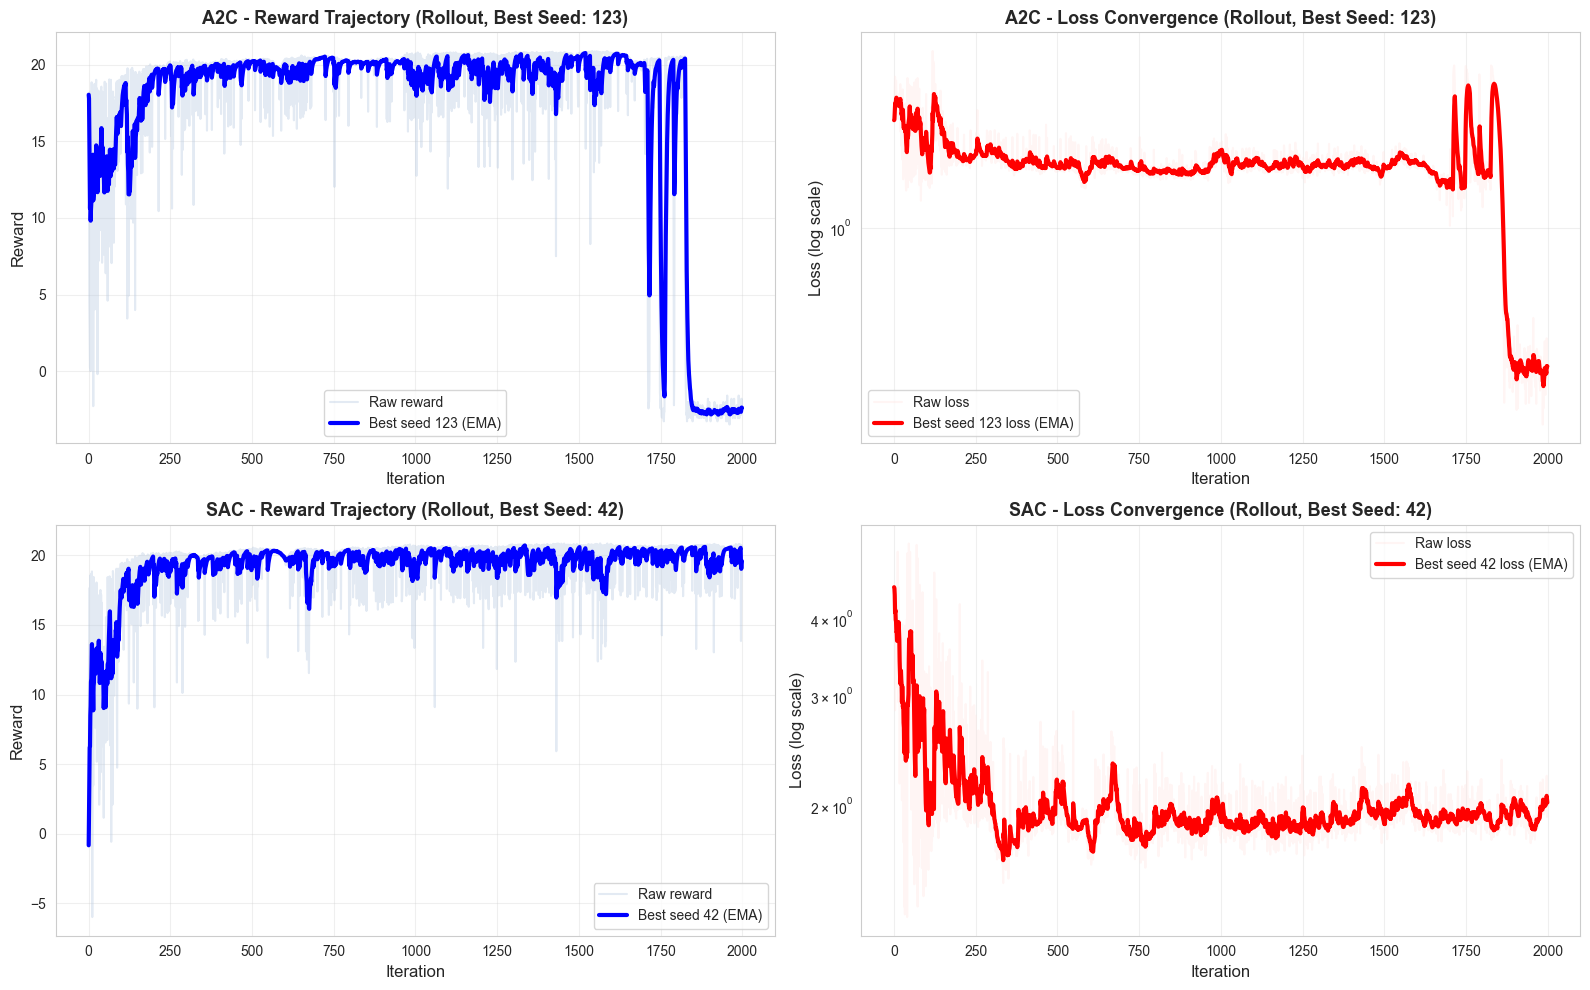

Saved: training_curves_rollout.png (best-seed curves)


In [7]:
# @title "Training Curves with Proper Rollout Collection"
# Plot rollout training curves for the BEST seed per model (selected by highest eval reward)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for idx, agent_name in enumerate(['a2c', 'sac']):
    histories = results_v3.get(agent_name, [])
    
    if len(histories) == 0:
        axes[idx, 0].text(0.5, 0.5, 'No successful runs', ha='center', va='center', fontsize=12, color='red')
        axes[idx, 0].set_title(f'{agent_name.upper()} - Rewards', fontsize=13, fontweight='bold')
        axes[idx, 1].text(0.5, 0.5, 'No successful runs', ha='center', va='center', fontsize=12, color='red')
        axes[idx, 1].set_title(f'{agent_name.upper()} - Losses', fontsize=13, fontweight='bold')
        continue
    
    # Select best seed by highest mean eval reward
    best_idx = int(np.argmax([h.get('mean_eval_reward', -np.inf) for h in histories]))
    best_hist = histories[best_idx]
    best_seed = best_hist['seed']
    
    # Rewards
    rewards = np.array(best_hist['rewards'], dtype=float)
    epochs = np.arange(len(rewards))
    ema_rewards = pd.Series(rewards).ewm(span=10, adjust=False).mean().values
    
    ax = axes[idx, 0]
    ax.plot(epochs, rewards, color='lightsteelblue', alpha=0.35, lw=1.5, label='Raw reward')
    ax.plot(epochs, ema_rewards, 'b-', lw=3, label=f'Best seed {best_seed} (EMA)')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title(f'{agent_name.upper()} - Reward Trajectory (Rollout, Best Seed: {best_seed})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Losses
    losses = np.array(best_hist['losses'], dtype=float)
    losses_safe = np.clip(losses, 1e-8, None)
    ema_loss = pd.Series(losses_safe).ewm(span=10, adjust=False).mean().values
    
    ax = axes[idx, 1]
    ax.semilogy(epochs, losses_safe, color='mistyrose', alpha=0.35, lw=1.5, label='Raw loss')
    ax.semilogy(epochs, ema_loss, 'r-', lw=3, label=f'Best seed {best_seed} loss (EMA)')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss (log scale)', fontsize=12)
    ax.set_title(f'{agent_name.upper()} - Loss Convergence (Rollout, Best Seed: {best_seed})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_rollout.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_curves_rollout.png (best-seed curves)")



SAC degradation diagnostics across seeds:
 seed  iters  best_eval_reward  pre_reward_mean  post_reward_mean  reward_delta_post_minus_pre  detected_drop_iter  detected_drop_magnitude  median_loss_pre  median_loss_post  loss_ratio_post_over_pre
   42   2000            20.926           15.615            19.821                        4.206                 200                   10.090         2.054466          1.885200                  0.917611
  123   2000            18.512           15.840            -5.095                      -20.935                1235                   26.808         1.940386         -0.148268                 -0.076411
  777   2000            20.482           14.678            -2.599                      -17.277                1014                   21.984         2.164605          0.243937                  0.112693


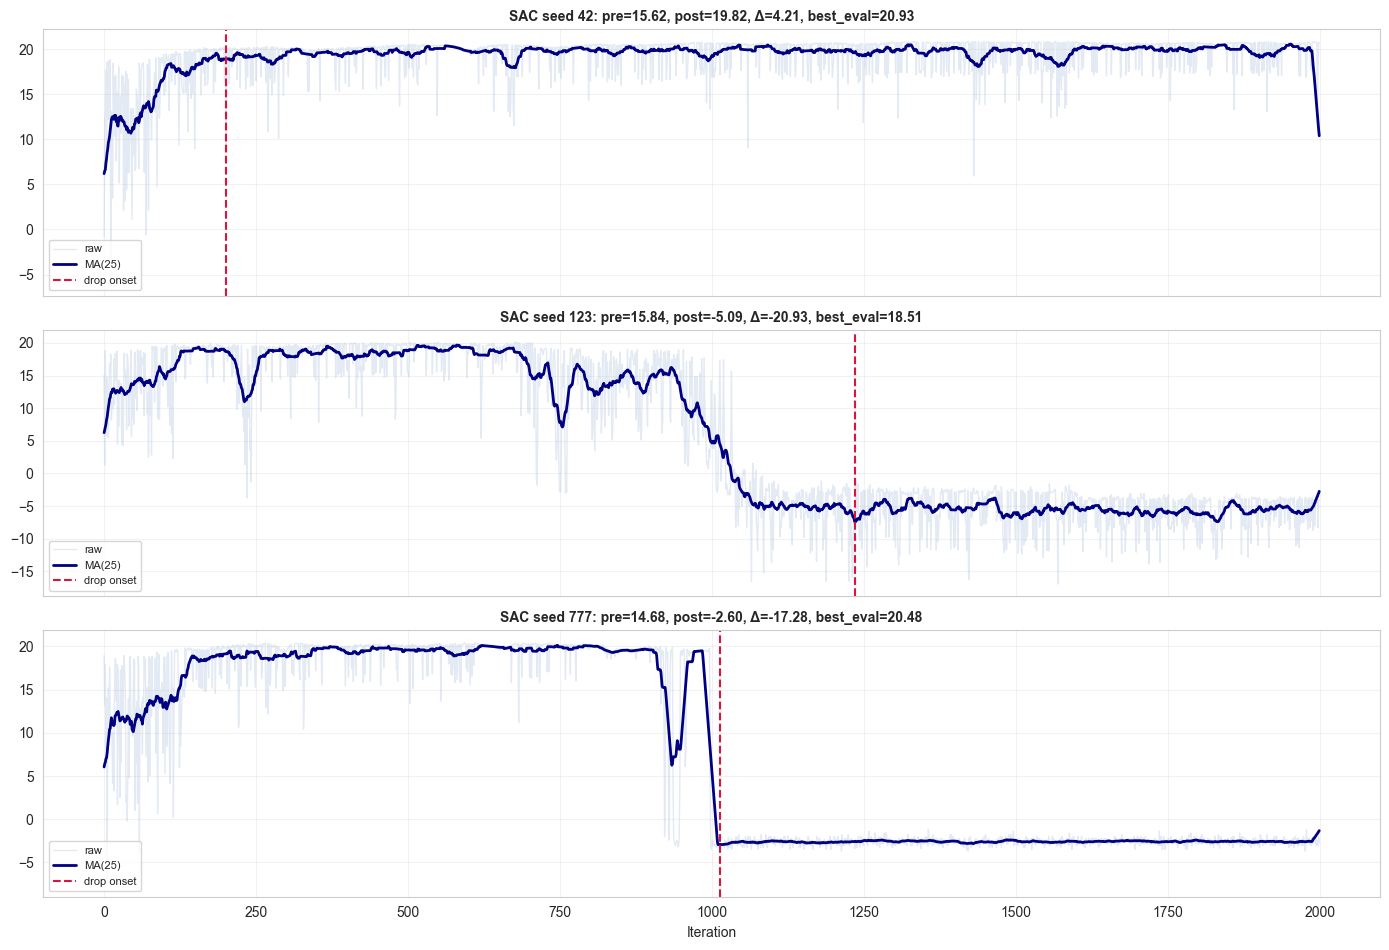


Saved: results/benchmark/sac_degradation_diagnostics.png


In [8]:
# SAC degradation forensics: identify onset, magnitude, and evaluation mismatch
if 'results_v3' not in globals() or 'sac' not in results_v3 or len(results_v3['sac']) == 0:
    raise RuntimeError("SAC rollout training results not found. Run Cell 13 first.")

def moving_avg(x, w=25):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x.copy()
    return np.convolve(x, np.ones(w)/w, mode='same')

def detect_drop_point(series, warmup=200, min_drop=5.0):
    s = np.asarray(series, dtype=float)
    if len(s) <= warmup + 20:
        return None, 0.0
    baseline = float(np.max(moving_avg(s[:warmup], w=min(25, max(3, warmup // 4)))))
    post = moving_avg(s[warmup:], w=25)
    worst_idx_rel = int(np.argmin(post))
    worst_val = float(post[worst_idx_rel])
    drop = baseline - worst_val
    if drop >= min_drop:
        return warmup + worst_idx_rel, drop
    return None, drop

rows = []
for h in results_v3['sac']:
    rewards = np.asarray(h.get('rewards', []), dtype=float)
    losses = np.asarray(h.get('losses', []), dtype=float)
    eval_best = float(h.get('mean_eval_reward', np.nan))
    seed = int(h.get('seed', -1))

    drop_idx, drop_mag = detect_drop_point(rewards, warmup=200, min_drop=5.0)

    pre_slice = rewards[:200] if len(rewards) >= 200 else rewards[:max(1, len(rewards)//2)]
    post_slice = rewards[1000:] if len(rewards) > 1000 else rewards[max(1, len(rewards)//2):]
    pre_mean = float(np.mean(pre_slice)) if len(pre_slice) else np.nan
    post_mean = float(np.mean(post_slice)) if len(post_slice) else np.nan

    pre_loss = float(np.median(losses[:300])) if len(losses) >= 300 else float(np.median(losses))
    post_loss = float(np.median(losses[1000:])) if len(losses) > 1000 else float(np.median(losses[max(1, len(losses)//2):]))

    rows.append({
        'seed': seed,
        'iters': len(rewards),
        'best_eval_reward': eval_best,
        'pre_reward_mean': round(pre_mean, 3),
        'post_reward_mean': round(post_mean, 3),
        'reward_delta_post_minus_pre': round(post_mean - pre_mean, 3),
        'detected_drop_iter': int(drop_idx) if drop_idx is not None else None,
        'detected_drop_magnitude': round(float(drop_mag), 3),
        'median_loss_pre': round(pre_loss, 6),
        'median_loss_post': round(post_loss, 6),
        'loss_ratio_post_over_pre': round((post_loss / pre_loss) if pre_loss != 0 else np.nan, 6),
    })

diag_df = pd.DataFrame(rows).sort_values('seed').reset_index(drop=True)
print('SAC degradation diagnostics across seeds:')
print(diag_df.to_string(index=False))

# Plot per-seed reward traces with detected drop markers
fig, axes = plt.subplots(len(rows), 1, figsize=(14, 3.2 * max(1, len(rows))), sharex=True)
if len(rows) == 1:
    axes = [axes]

for ax, row in zip(axes, rows):
    seed = row['seed']
    h = [x for x in results_v3['sac'] if int(x.get('seed', -1)) == seed][0]
    r = np.asarray(h['rewards'], dtype=float)
    ema = moving_avg(r, w=25)
    ax.plot(r, color='lightsteelblue', alpha=0.35, lw=1.0, label='raw')
    ax.plot(ema, color='navy', lw=2.0, label='MA(25)')
    if row['detected_drop_iter'] is not None:
        ax.axvline(row['detected_drop_iter'], color='crimson', linestyle='--', lw=1.5, label='drop onset')
    ax.set_title(
        f"SAC seed {seed}: pre={row['pre_reward_mean']:.2f}, post={row['post_reward_mean']:.2f}, Δ={row['reward_delta_post_minus_pre']:.2f}, best_eval={row['best_eval_reward']:.2f}",
        fontsize=10,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc='lower left')

axes[-1].set_xlabel('Iteration')
plt.tight_layout()
sac_diag_path = OUTPUT_DIR / 'sac_degradation_diagnostics.png'
plt.savefig(sac_diag_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: {sac_diag_path}")

In [9]:
# Inspect active SAC update implementation in current kernel (sanity check)
import inspect
from src.agents.sac_agent import SACAgent

src_update = inspect.getsource(SACAgent.update)
print('SACAgent.update source header:')
print('\n'.join(src_update.splitlines()[:25]))

print('\nContains replay push in update?:', 'replay_buffer.push' in src_update)

SACAgent.update source header:
    def update(
        self,
        batch: Dict[str, Any],
    ) -> Dict[str, float]:
        """Update agent from replay buffer batch."""
        if len(self.replay_buffer) < self.batch_size:
            return {}
        
        # Sample batch
        batch = self.replay_buffer.sample(self.batch_size)
        
        return self._update_networks(batch)

Contains replay push in update?: False


In [10]:
# Check SAC history consistency with active SAC.update implementation
if 'results_v3' not in globals() or 'sac' not in results_v3:
    print('results_v3 or sac key missing')
else:
    print('SAC history quick consistency:')
    for h in results_v3['sac']:
        losses = np.asarray(h.get('losses', []), dtype=float)
        nonzero = int(np.sum(np.abs(losses) > 1e-12))
        print(
            f"seed={h.get('seed')}, len={len(losses)}, nonzero_losses={nonzero}, "
            f"min={losses.min() if len(losses)>0 else np.nan:.6f}, max={losses.max() if len(losses)>0 else np.nan:.6f}, "
            f"first5={np.round(losses[:5], 6).tolist()}"
        )

SAC history quick consistency:
seed=42, len=2000, nonzero_losses=2000, min=1.322208, max=5.283902, first5=[4.493288, 4.382817, 3.893695, 2.846183, 4.2885]
seed=123, len=2000, nonzero_losses=2000, min=-4.747677, max=5.565812, first5=[3.991033, 3.635695, 3.274522, 4.446744, 3.936223]
seed=777, len=2000, nonzero_losses=2000, min=-0.755029, max=5.990127, first5=[3.602408, 3.974477, 2.990901, 4.579565, 4.059775]


Generating depot-to-customer order visualization from trained checkpoints...
Using checkpoints from: results/benchmark/checkpoints_v3


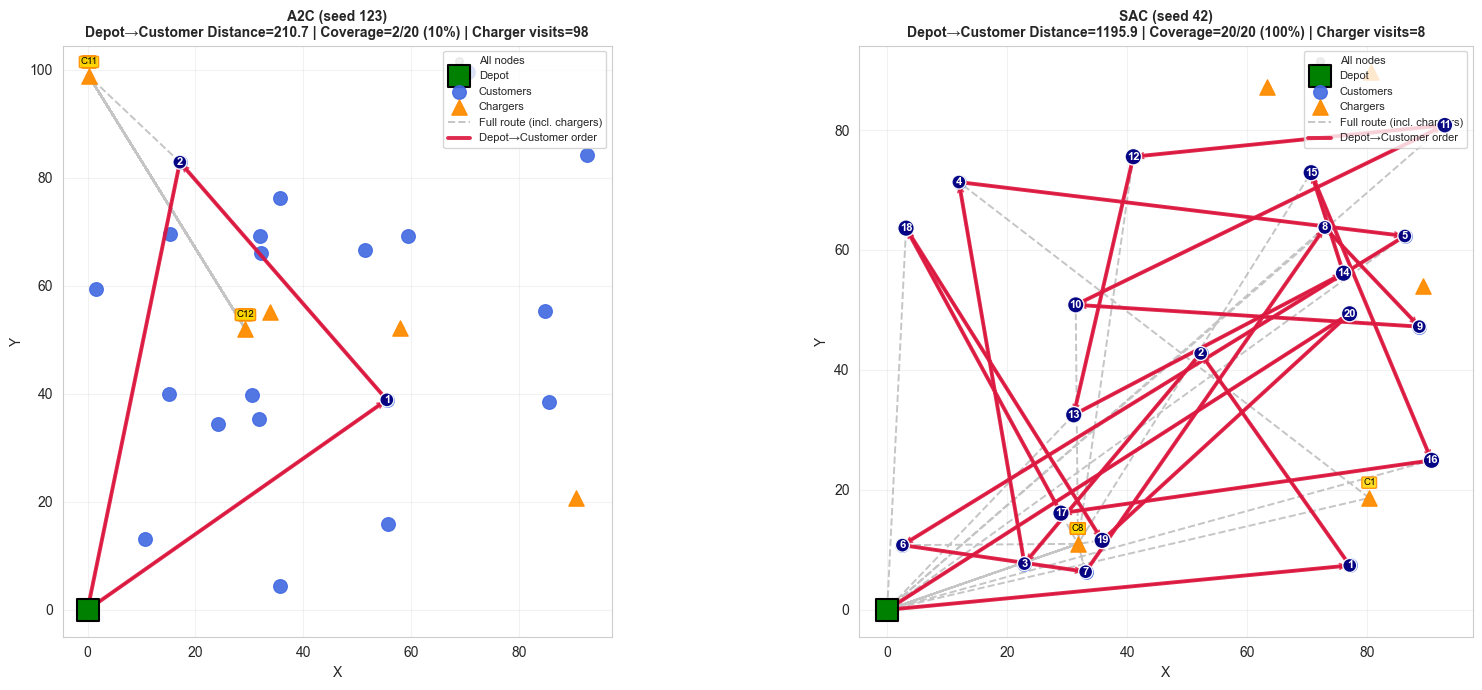


Depot-to-customer order summary (with charger visits):
agent  seed  coverage_pct  charger_visits  steps                                order_head                            charger_head
  A2C   123          10.0              98    100                                   [5, 20] [23, 25, 23, 25, 23, 25, 23, 25, '...']
  SAC    42         100.0               8     36 [2, 12, 18, 9, 4, 13, 5, 7, 8, 15, '...']        [22, 25, 25, 25, 25, 25, 25, 25]

Saved: results/benchmark/depot_to_customer_order_trained_agents.png


In [11]:
# REAL Route Visualization from Trained Agents (Depot-to-Customer Order + Charger Visits)
from pathlib import Path

print("Generating depot-to-customer order visualization from trained checkpoints...")


def resolve_checkpoint_dir(output_dir: Path) -> Path:
    candidates = [
        output_dir / 'checkpoints_v3',
        Path('examples') / output_dir / 'checkpoints_v3',
        Path('results/benchmark/checkpoints_v3'),
        Path('examples/results/benchmark/checkpoints_v3'),
    ]
    for c in candidates:
        if c.exists() and any(c.glob('*_best_v3.pt')):
            return c
    raise FileNotFoundError(
        'No checkpoints_v3 directory with *_best_v3.pt files found. Run the fixed training cell first.'
    )


checkpoint_dir = resolve_checkpoint_dir(OUTPUT_DIR)
print(f"Using checkpoints from: {checkpoint_dir}")


def select_best_seed(agent_name: str) -> int:
    if 'results_v3' in globals() and agent_name in results_v3 and len(results_v3[agent_name]) > 0:
        best_idx = int(np.argmax([h.get('mean_eval_reward', -np.inf) for h in results_v3[agent_name]]))
        return int(results_v3[agent_name][best_idx]['seed'])

    available = sorted(checkpoint_dir.glob(f'{agent_name}_seed*_best_v3.pt'))
    if not available:
        raise FileNotFoundError(f'No checkpoint found for {agent_name.upper()} in {checkpoint_dir}')

    stem = available[0].stem
    seed_str = stem.split('_seed')[1].split('_')[0]
    return int(seed_str)


def run_agent_route(agent, env_config: dict, max_steps: int = 200):
    env = EnvFactory.create(env_config)
    obs, _ = env.reset()

    full_route = [int(env.current_node)]
    total_reward = 0.0
    total_distance = 0.0
    customer_visit_order = []
    charger_visit_order = []
    visited_customers = set()
    num_customers = int(getattr(env, 'num_customers', 0))

    done = False
    steps = 0

    agent.eval()
    with torch.no_grad():
        while not done and steps < max_steps:
            action, _ = agent.select_action(obs, deterministic=True)
            action = int(action)

            step_result = env.step(action)
            if len(step_result) == 5:
                obs, reward, terminated, truncated, info = step_result
                done = bool(terminated or truncated)
            else:
                obs, reward, done, info = step_result

            total_reward += float(reward)
            total_distance += float(info.get('distance', 0.0))
            full_route.append(action)

            if 1 <= action <= num_customers and action not in visited_customers:
                visited_customers.add(action)
                customer_visit_order.append(action)
            elif action > num_customers:
                charger_visit_order.append(action)

            steps += 1

    depot_customer_route = [0] + customer_visit_order + [0]
    node_coords = env.node_coords.copy() if hasattr(env, 'node_coords') else None
    return {
        'full_route': full_route,
        'depot_customer_route': depot_customer_route,
        'customer_visit_order': customer_visit_order,
        'charger_visit_order': charger_visit_order,
        'reward': total_reward,
        'distance': total_distance,
        'steps': steps,
        'visited_customers': len(visited_customers),
        'num_customers': num_customers,
        'node_coords': node_coords,
        'env': env,
    }


def route_distance(route, distance_matrix):
    if len(route) < 2:
        return 0.0
    total = 0.0
    for i in range(len(route) - 1):
        total += float(distance_matrix[route[i], route[i + 1]])
    return total


def plot_depot_customer_order(ax, route_data: dict, title: str):
    env = route_data['env']
    coords = route_data['node_coords']

    if coords is None:
        ax.text(0.5, 0.5, 'No coordinates available', ha='center', va='center')
        ax.set_title(title)
        return

    num_customers = route_data['num_customers']
    num_chargers = int(getattr(env, 'num_chargers', 0))

    # Background nodes
    ax.scatter(coords[:, 0], coords[:, 1], c='lightgray', s=30, alpha=0.35, label='All nodes')

    # Depot
    ax.scatter(coords[0, 0], coords[0, 1], c='green', s=240, marker='s', edgecolors='black', linewidths=1.5, label='Depot', zorder=6)

    # Customers and chargers
    if num_customers > 0:
        customer_idx = np.arange(1, num_customers + 1)
        ax.scatter(coords[customer_idx, 0], coords[customer_idx, 1], c='royalblue', s=95, marker='o', alpha=0.9, label='Customers', zorder=4)

    if num_chargers > 0:
        charger_start = num_customers + 1
        charger_end = num_customers + num_chargers + 1
        charger_idx = np.arange(charger_start, charger_end)
        ax.scatter(coords[charger_idx, 0], coords[charger_idx, 1], c='darkorange', s=120, marker='^', alpha=0.95, label='Chargers', zorder=4)

    # Full route with charger visits (faint line)
    full_route = [node for node in route_data['full_route'] if 0 <= node < len(coords)]
    if len(full_route) > 1:
        full_coords = coords[full_route]
        ax.plot(full_coords[:, 0], full_coords[:, 1], '--', color='gray', lw=1.4, alpha=0.45, label='Full route (incl. chargers)', zorder=2)

    # Depot -> customer first-visit order -> depot (main line)
    route = [node for node in route_data['depot_customer_route'] if 0 <= node < len(coords)]
    if len(route) > 1:
        route_coords = coords[route]
        ax.plot(route_coords[:, 0], route_coords[:, 1], '-', color='crimson', lw=2.8, alpha=0.9, label='Depot→Customer order', zorder=5)

        for i in range(len(route) - 1):
            x0, y0 = route_coords[i]
            x1, y1 = route_coords[i + 1]
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2, alpha=0.8))

        # Number each customer by first-visit order
        for k, customer_node in enumerate(route_data['customer_visit_order'], 1):
            x, y = coords[customer_node]
            ax.text(
                x,
                y,
                str(k),
                fontsize=8,
                ha='center',
                va='center',
                color='white',
                fontweight='bold',
                bbox=dict(boxstyle='circle,pad=0.18', facecolor='navy', edgecolor='white', alpha=0.95),
                zorder=7,
            )

    # Label first few charger visits as C1, C2, ...
    for k, charger_node in enumerate(route_data['charger_visit_order'][:12], 1):
        if 0 <= charger_node < len(coords):
            x, y = coords[charger_node]
            ax.text(
                x,
                y + 1.8,
                f'C{k}',
                fontsize=7,
                ha='center',
                va='bottom',
                color='black',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='gold', edgecolor='darkorange', alpha=0.85),
                zorder=8,
            )

    dep_cust_dist = route_distance(route, env.distance_matrix if hasattr(env, 'distance_matrix') else np.zeros((1, 1)))
    coverage = 100.0 * route_data['visited_customers'] / max(route_data['num_customers'], 1)
    charger_visits = len(route_data['charger_visit_order'])
    subtitle = (
        f"Depot→Customer Distance={dep_cust_dist:.1f} | Coverage={route_data['visited_customers']}/{route_data['num_customers']} ({coverage:.0f}%) | Charger visits={charger_visits}"
    )

    ax.set_title(f"{title}\n{subtitle}", fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8, loc='upper right')


fig, axes = plt.subplots(1, 2, figsize=(17, 7))
summary_rows = []

for i, agent_name in enumerate(['a2c', 'sac']):
    try:
        best_seed = select_best_seed(agent_name)
        ckpt_path = checkpoint_dir / f'{agent_name}_seed{best_seed}_best_v3.pt'
        if not ckpt_path.exists():
            matches = sorted(checkpoint_dir.glob(f'{agent_name}_seed*_best_v3.pt'))
            if not matches:
                raise FileNotFoundError(f'No checkpoint file for {agent_name.upper()}')
            ckpt_path = matches[0]
            best_seed = int(ckpt_path.stem.split('_seed')[1].split('_')[0])

        checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
        agent_config = checkpoint['config']
        env_config = checkpoint.get('env_config', {
            'num_customers': 20,
            'num_chargers': 5,
            'max_battery': 500.0,
            'seed': best_seed,
        })

        temp_env = EnvFactory.create(env_config)
        action_dim = temp_env.action_space.n if hasattr(temp_env.action_space, 'n') else temp_env.action_space.shape[0]

        trained_agent = AgentFactory.create(agent_config, action_dim=action_dim)
        trained_agent.load_state_dict(checkpoint['agent_state_dict'])
        trained_agent.to(device)

        route_data = run_agent_route(trained_agent, env_config, max_steps=200)
        plot_depot_customer_order(axes[i], route_data, f"{agent_name.upper()} (seed {best_seed})")

        order_preview = route_data['customer_visit_order'][:10]
        if len(route_data['customer_visit_order']) > 10:
            order_preview = order_preview + ['...']

        charger_preview = route_data['charger_visit_order'][:8]
        if len(route_data['charger_visit_order']) > 8:
            charger_preview = charger_preview + ['...']

        summary_rows.append({
            'agent': agent_name.upper(),
            'seed': best_seed,
            'coverage_pct': round(100.0 * route_data['visited_customers'] / max(route_data['num_customers'], 1), 1),
            'charger_visits': len(route_data['charger_visit_order']),
            'steps': route_data['steps'],
            'order_head': str(order_preview),
            'charger_head': str(charger_preview),
        })

    except Exception as e:
        axes[i].text(0.5, 0.5, f'Failed: {type(e).__name__}\n{str(e)[:120]}', ha='center', va='center', color='red')
        axes[i].set_title(f'{agent_name.upper()} route unavailable')
        axes[i].set_axis_off()

plt.tight_layout()
out_path = OUTPUT_DIR / 'depot_to_customer_order_trained_agents.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("\nDepot-to-customer order summary (with charger visits):")
    print(summary_df.to_string(index=False))

print(f"\nSaved: {out_path}")

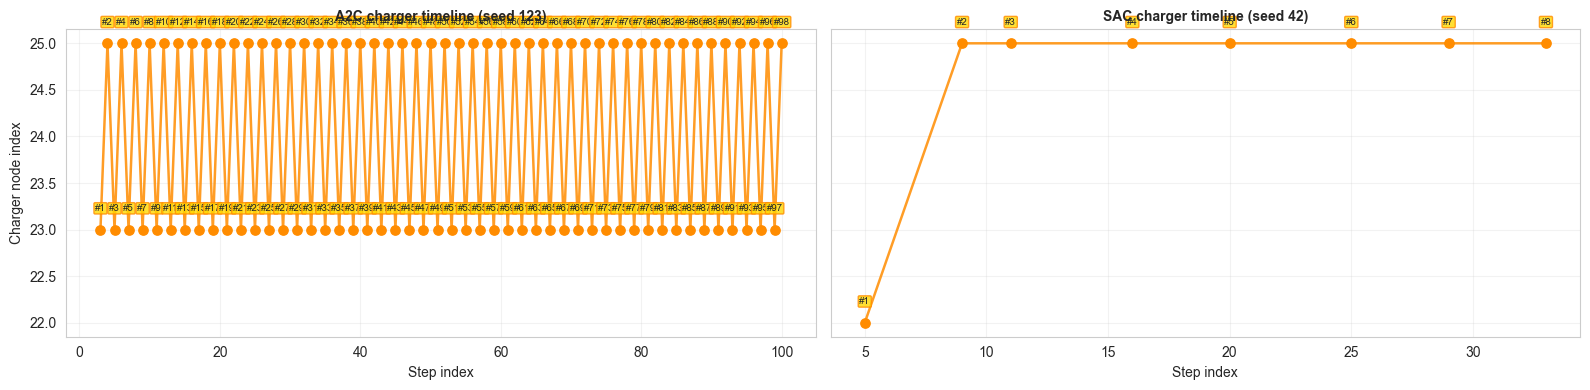


Charger timeline summary:
agent  seed  charger_visits  unique_chargers charger_nodes
  A2C   123              98                2      [23, 25]
  SAC    42               8                2      [22, 25]

Saved: results/benchmark/charger_visit_timeline.png


In [12]:
# Charger-Visit Timeline (explicit per-visit visibility)
# Shows every charger visit in chronological order to avoid overlap ambiguity in spatial plots.

if 'run_agent_route' not in globals() or 'select_best_seed' not in globals() or 'resolve_checkpoint_dir' not in globals():
    raise RuntimeError("Run Cell 15 first to define route helper functions.")

checkpoint_dir = resolve_checkpoint_dir(OUTPUT_DIR)


def collect_route_with_steps(agent, env_config: dict, max_steps: int = 200):
    env = EnvFactory.create(env_config)
    obs, _ = env.reset()
    num_customers = int(getattr(env, 'num_customers', 0))

    step_idx = 0
    charger_step_sequence = []  # (step, charger_node, visit_order)

    done = False
    agent.eval()
    with torch.no_grad():
        while not done and step_idx < max_steps:
            action, _ = agent.select_action(obs, deterministic=True)
            action = int(action)

            step_result = env.step(action)
            if len(step_result) == 5:
                obs, reward, terminated, truncated, info = step_result
                done = bool(terminated or truncated)
            else:
                obs, reward, done, info = step_result

            if action > num_customers:
                charger_step_sequence.append((step_idx + 1, action, len(charger_step_sequence) + 1))

            step_idx += 1

    return {
        'num_steps': step_idx,
        'charger_steps': charger_step_sequence,
        'num_customers': num_customers,
    }


fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

timeline_rows = []

for i, agent_name in enumerate(['a2c', 'sac']):
    ax = axes[i]
    try:
        best_seed = select_best_seed(agent_name)
        ckpt_path = checkpoint_dir / f'{agent_name}_seed{best_seed}_best_v3.pt'
        if not ckpt_path.exists():
            matches = sorted(checkpoint_dir.glob(f'{agent_name}_seed*_best_v3.pt'))
            if not matches:
                raise FileNotFoundError(f'No checkpoint for {agent_name.upper()}')
            ckpt_path = matches[0]
            best_seed = int(ckpt_path.stem.split('_seed')[1].split('_')[0])

        checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
        agent_config = checkpoint['config']
        env_config = checkpoint.get('env_config', {
            'num_customers': 20,
            'num_chargers': 5,
            'max_battery': 500.0,
            'seed': best_seed,
        })

        temp_env = EnvFactory.create(env_config)
        action_dim = temp_env.action_space.n if hasattr(temp_env.action_space, 'n') else temp_env.action_space.shape[0]

        trained_agent = AgentFactory.create(agent_config, action_dim=action_dim)
        trained_agent.load_state_dict(checkpoint['agent_state_dict'])
        trained_agent.to(device)

        timeline = collect_route_with_steps(trained_agent, env_config, max_steps=200)
        charger_steps = timeline['charger_steps']

        if charger_steps:
            x = [t[0] for t in charger_steps]
            y = [t[1] for t in charger_steps]
            visit_order = [t[2] for t in charger_steps]

            ax.plot(x, y, '-', color='darkorange', lw=1.8, alpha=0.85)
            ax.scatter(x, y, c='darkorange', s=45, zorder=3)

            for sx, sy, order in zip(x, y, visit_order):
                ax.text(
                    sx,
                    sy + 0.18,
                    f'#{order}',
                    fontsize=7,
                    ha='center',
                    va='bottom',
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='gold', edgecolor='darkorange', alpha=0.8),
                )

            unique_nodes = sorted(set(y))
            timeline_rows.append({
                'agent': agent_name.upper(),
                'seed': best_seed,
                'charger_visits': len(charger_steps),
                'unique_chargers': len(unique_nodes),
                'charger_nodes': str(unique_nodes),
            })
        else:
            ax.text(0.5, 0.5, 'No charger visits', transform=ax.transAxes, ha='center', va='center')
            timeline_rows.append({
                'agent': agent_name.upper(),
                'seed': best_seed,
                'charger_visits': 0,
                'unique_chargers': 0,
                'charger_nodes': '[]',
            })

        ax.set_title(f"{agent_name.upper()} charger timeline (seed {best_seed})", fontsize=10, fontweight='bold')
        ax.set_xlabel('Step index')
        ax.grid(True, alpha=0.25)

    except Exception as e:
        ax.text(0.5, 0.5, f'Failed: {type(e).__name__}', transform=ax.transAxes, ha='center', va='center', color='red')
        ax.set_title(f"{agent_name.upper()} timeline unavailable")

axes[0].set_ylabel('Charger node index')
plt.tight_layout()

timeline_path = OUTPUT_DIR / 'charger_visit_timeline.png'
plt.savefig(timeline_path, dpi=300, bbox_inches='tight')
plt.show()

if timeline_rows:
    timeline_df = pd.DataFrame(timeline_rows)
    print("\nCharger timeline summary:")
    print(timeline_df.to_string(index=False))

print(f"\nSaved: {timeline_path}")

In [13]:
# Export full depot-to-customer visit order for report/paper use
if 'run_agent_route' not in globals() or 'select_best_seed' not in globals() or 'resolve_checkpoint_dir' not in globals():
    raise RuntimeError("Run Cell 15 first (Depot-to-Customer visualization) to define helper functions.")

checkpoint_dir = resolve_checkpoint_dir(OUTPUT_DIR)
export_rows = []

for agent_name in ['a2c', 'sac']:
    best_seed = select_best_seed(agent_name)
    ckpt_path = checkpoint_dir / f'{agent_name}_seed{best_seed}_best_v3.pt'
    if not ckpt_path.exists():
        matches = sorted(checkpoint_dir.glob(f'{agent_name}_seed*_best_v3.pt'))
        if not matches:
            print(f"Skipping {agent_name.upper()}: checkpoint not found")
            continue
        ckpt_path = matches[0]
        best_seed = int(ckpt_path.stem.split('_seed')[1].split('_')[0])

    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    agent_config = checkpoint['config']
    env_config = checkpoint.get('env_config', {
        'num_customers': 20,
        'num_chargers': 5,
        'max_battery': 500.0,
        'seed': best_seed,
    })

    temp_env = EnvFactory.create(env_config)
    action_dim = temp_env.action_space.n if hasattr(temp_env.action_space, 'n') else temp_env.action_space.shape[0]

    trained_agent = AgentFactory.create(agent_config, action_dim=action_dim)
    trained_agent.load_state_dict(checkpoint['agent_state_dict'])
    trained_agent.to(device)

    route_data = run_agent_route(trained_agent, env_config, max_steps=200)

    for visit_rank, customer_node in enumerate(route_data['customer_visit_order'], 1):
        export_rows.append({
            'agent': agent_name.upper(),
            'seed': best_seed,
            'visit_rank': visit_rank,
            'customer_node': int(customer_node),
        })

if not export_rows:
    raise RuntimeError("No route orders available for export.")

order_long_df = pd.DataFrame(export_rows).sort_values(['agent', 'visit_rank']).reset_index(drop=True)
order_wide_df = order_long_df.pivot_table(
    index='visit_rank', columns='agent', values='customer_node', aggfunc='first'
).reset_index()

long_csv_path = OUTPUT_DIR / 'depot_to_customer_full_order_long.csv'
wide_csv_path = OUTPUT_DIR / 'depot_to_customer_full_order_wide.csv'

order_long_df.to_csv(long_csv_path, index=False)
order_wide_df.to_csv(wide_csv_path, index=False)

print("Saved full order CSV files:")
print(f"  - {long_csv_path}")
print(f"  - {wide_csv_path}")
print("\nPreview (wide format):")
print(order_wide_df.head(10).to_string(index=False))

Saved full order CSV files:
  - results/benchmark/depot_to_customer_full_order_long.csv
  - results/benchmark/depot_to_customer_full_order_wide.csv

Preview (wide format):
 visit_rank  A2C  SAC
          1  5.0  2.0
          2 20.0 12.0
          3  NaN 18.0
          4  NaN  9.0
          5  NaN  4.0
          6  NaN 13.0
          7  NaN  5.0
          8  NaN  7.0
          9  NaN  8.0
         10  NaN 15.0


In [14]:
# Combined route trace bundle export (step trace + customer order + charger order)
if 'select_best_seed' not in globals() or 'resolve_checkpoint_dir' not in globals():
    raise RuntimeError("Run Cell 15 first to initialize helper functions.")

checkpoint_dir = resolve_checkpoint_dir(OUTPUT_DIR)
bundle_rows = []
bundle_summary_rows = []

for agent_name in ['a2c', 'sac']:
    best_seed = select_best_seed(agent_name)
    ckpt_path = checkpoint_dir / f'{agent_name}_seed{best_seed}_best_v3.pt'
    if not ckpt_path.exists():
        matches = sorted(checkpoint_dir.glob(f'{agent_name}_seed*_best_v3.pt'))
        if not matches:
            print(f"Skipping {agent_name.upper()}: checkpoint not found")
            continue
        ckpt_path = matches[0]
        best_seed = int(ckpt_path.stem.split('_seed')[1].split('_')[0])

    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    agent_config = checkpoint['config']
    env_config = checkpoint.get('env_config', {
        'num_customers': 20,
        'num_chargers': 5,
        'max_battery': 500.0,
        'seed': best_seed,
    })

    env = EnvFactory.create(env_config)
    action_dim = env.action_space.n if hasattr(env.action_space, 'n') else env.action_space.shape[0]
    trained_agent = AgentFactory.create(agent_config, action_dim=action_dim)
    trained_agent.load_state_dict(checkpoint['agent_state_dict'])
    trained_agent.to(device)
    trained_agent.eval()

    obs, _ = env.reset()
    num_customers = int(getattr(env, 'num_customers', 0))
    charger_start = num_customers + 1
    max_steps = 200

    visited_customers = set()
    customer_order = []
    charger_order = []

    done = False
    step_idx = 0
    with torch.no_grad():
        while not done and step_idx < max_steps:
            action, _ = trained_agent.select_action(obs, deterministic=True)
            action = int(action)

            if action == 0:
                node_type = 'depot'
            elif 1 <= action <= num_customers:
                node_type = 'customer'
                if action not in visited_customers:
                    visited_customers.add(action)
                    customer_order.append(action)
            elif action >= charger_start:
                node_type = 'charger'
                charger_order.append(action)
            else:
                node_type = 'other'

            step_result = env.step(action)
            if len(step_result) == 5:
                obs, reward, terminated, truncated, info = step_result
                done = bool(terminated or truncated)
            else:
                obs, reward, done, info = step_result

            bundle_rows.append({
                'agent': agent_name.upper(),
                'seed': best_seed,
                'step': step_idx + 1,
                'action_node': action,
                'node_type': node_type,
                'reward': float(reward),
                'distance': float(info.get('distance', 0.0)),
                'battery': float(info.get('battery', np.nan)),
                'done': bool(done),
            })

            step_idx += 1

    bundle_summary_rows.append({
        'agent': agent_name.upper(),
        'seed': best_seed,
        'steps': step_idx,
        'visited_customers': len(visited_customers),
        'customer_order': customer_order,
        'charger_visits': len(charger_order),
        'charger_order': charger_order,
    })

if not bundle_rows:
    raise RuntimeError('No route traces were generated.')

trace_df = pd.DataFrame(bundle_rows)
summary_df = pd.DataFrame(bundle_summary_rows)

trace_csv_path = OUTPUT_DIR / 'agent_route_step_trace.csv'
summary_csv_path = OUTPUT_DIR / 'agent_route_sequence_summary.csv'
summary_json_path = OUTPUT_DIR / 'agent_route_sequence_summary.json'

trace_df.to_csv(trace_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)
summary_df.to_json(summary_json_path, orient='records', indent=2)

print('Saved combined route bundle:')
print(f'  - {trace_csv_path}')
print(f'  - {summary_csv_path}')
print(f'  - {summary_json_path}')
print('\nSequence summary:')
print(summary_df[['agent', 'seed', 'steps', 'visited_customers', 'charger_visits']].to_string(index=False))

Saved combined route bundle:
  - results/benchmark/agent_route_step_trace.csv
  - results/benchmark/agent_route_sequence_summary.csv
  - results/benchmark/agent_route_sequence_summary.json

Sequence summary:
agent  seed  steps  visited_customers  charger_visits
  A2C   123    100                  2              98
  SAC    42     36                 20               8


## 9. XAI Analysis - Feature Importance

In [15]:
if not importance_records:
    raise RuntimeError('No XAI records generated. Ensure checkpoints are available and Cell 15 has been run.')

importance_df = pd.DataFrame(importance_records)
interaction_df = pd.DataFrame(interaction_records)

# Create absolute importance (magnitude) + interaction heatmaps figure (2x2)
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 11))
agents = ['A2C', 'SAC']

for col, agent_label in enumerate(agents):
    imp_sub = importance_df[importance_df['agent'] == agent_label].copy()
    imp_sub['abs_importance'] = np.abs(imp_sub['importance'])
    imp_sub = imp_sub.sort_values('abs_importance', ascending=False)

    ax_bar = axes1[0, col]
    if len(imp_sub) > 0:
        colors = ['steelblue' if x >= 0 else 'coral' for x in imp_sub['importance']]
        ax_bar.barh(imp_sub['feature'], imp_sub['abs_importance'], color=colors, alpha=0.85)
        ax_bar.invert_yaxis()
    ax_bar.set_title(f'{agent_label} Feature Importance (Absolute Magnitude)', fontsize=12, fontweight='bold')
    ax_bar.set_xlabel('|Perturbation Effect| (absolute)', fontsize=11)
    ax_bar.grid(True, axis='x', alpha=0.3)

    inter_sub = interaction_df[interaction_df['agent'] == agent_label]
    mat = np.zeros((len(FEATURE_KEYS), len(FEATURE_KEYS)), dtype=float)
    idx_map = {f: i for i, f in enumerate(FEATURE_KEYS)}
    for _, row in inter_sub.iterrows():
        i = idx_map[row['feature_i']]
        j = idx_map[row['feature_j']]
        mat[i, j] = float(row['interaction'])
        mat[j, i] = float(row['interaction'])

    ax_hm = axes1[1, col]
    im = ax_hm.imshow(mat, cmap='YlOrRd')
    ax_hm.set_xticks(np.arange(len(FEATURE_KEYS)))
    ax_hm.set_yticks(np.arange(len(FEATURE_KEYS)))
    ax_hm.set_xticklabels(FEATURE_KEYS, rotation=35, ha='right', fontsize=9)
    ax_hm.set_yticklabels(FEATURE_KEYS, fontsize=9)
    ax_hm.set_title(f'{agent_label} Feature Interaction Strength', fontsize=12, fontweight='bold')
    for i in range(len(FEATURE_KEYS)):
        for j in range(len(FEATURE_KEYS)):
            if i != j:
                ax_hm.text(j, i, f"{mat[i, j]:.2e}", ha='center', va='center', fontsize=6, color='black')
    cbar = plt.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
xai_abs_path = OUTPUT_DIR / 'xai_trained_agents_absolute_importance_interactions.png'
plt.savefig(xai_abs_path, dpi=300, bbox_inches='tight')
plt.show()

# Create signed importance figure (showing direction + magnitude)
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

for col, agent_label in enumerate(agents):
    imp_sub = importance_df[importance_df['agent'] == agent_label].copy()
    imp_sub = imp_sub.sort_values('importance', ascending=True)  # Sort by signed value

    ax = axes2[col]
    if len(imp_sub) > 0:
        colors = ['coral' if x < 0 else 'steelblue' for x in imp_sub['importance']]
        ax.barh(imp_sub['feature'], imp_sub['importance'], color=colors, alpha=0.85)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(f'{agent_label} Feature Importance (Signed)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Perturbation Effect (negative=decreases confidence, positive=increases)', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
xai_signed_path = OUTPUT_DIR / 'xai_trained_agents_signed_importance.png'
plt.savefig(xai_signed_path, dpi=300, bbox_inches='tight')
plt.show()

# Save all three CSV versions: raw, absolute, and summary
importance_csv_path = OUTPUT_DIR / 'xai_trained_feature_importance_signed.csv'
importance_abs_csv_path = OUTPUT_DIR / 'xai_trained_feature_importance_absolute.csv'
interaction_csv_path = OUTPUT_DIR / 'xai_trained_feature_interactions.csv'

importance_df.to_csv(importance_csv_path, index=False)

# Create absolute importance version for export
importance_abs_df = importance_df.copy()
importance_abs_df['importance'] = np.abs(importance_abs_df['importance'])
importance_abs_df.to_csv(importance_abs_csv_path, index=False)

interaction_df.to_csv(interaction_csv_path, index=False)

# Create summary table
summary_xai = []
for agent_label in agents:
    agent_data = importance_df[importance_df['agent'] == agent_label]
    top_3 = agent_data.nlargest(3, 'importance')[['feature', 'importance']]
    for idx, row in top_3.iterrows():
        summary_xai.append({
            'agent': agent_label,
            'rank': len(summary_xai) % 3 + 1,
            'feature': row['feature'],
            'signed_importance': float(row['importance']),
            'abs_importance': float(np.abs(row['importance'])),
        })

summary_xai_df = pd.DataFrame(summary_xai)
summary_xai_csv_path = OUTPUT_DIR / 'xai_trained_feature_importance_summary.csv'
summary_xai_df.to_csv(summary_xai_csv_path, index=False)

print('Saved trained-agent XAI artifacts:')
print(f'  - {xai_abs_path}')
print(f'  - {xai_signed_path}')
print(f'  - {importance_csv_path}')
print(f'  - {importance_abs_csv_path}')
print(f'  - {interaction_csv_path}')
print(f'  - {summary_xai_csv_path}')

print('\n Feature Importance Summary (Top-3 per agent):')
print(summary_xai_df.to_string(index=False))

print('\n🔗 Interaction Insight (Top-5 strongest pairwise effects):')
interaction_sorted = interaction_df.nlargest(5, 'interaction')[['agent', 'feature_i', 'feature_j', 'interaction']]
print(interaction_sorted.to_string(index=False))

NameError: name 'importance_records' is not defined